## Remove duplicates, add splits, rename columns

In [24]:
import pandas as pd
BASE_DIR = "/vol/ideadata/ed52egek/data/isic_2020"
duplicates = pd.read_csv(BASE_DIR + "/ISIC_2020_Training_Duplicates.csv")
data = pd.read_csv(BASE_DIR + "/ISIC_2020_Training_GroundTruth_v2.csv")



In [25]:
# Collect all duplicate image names into one set
dup_images = set(duplicates["image_name_2"])

# Remove all rows where image_name is in the duplicates set
cleaned_data = data[~data["image_name"].isin(dup_images)].reset_index(drop=True)

# Save back to CSV (optional)
cleaned_data.to_csv(BASE_DIR + "/ISIC_2020_Training_GroundTruth_cleaned.csv", index=False)

print(f"Removed {len(data) - len(cleaned_data)} duplicates. Final dataset has {len(cleaned_data)} entries.")

Removed 425 duplicates. Final dataset has 32701 entries.


In [26]:
cleaned_data = cleaned_data.rename(columns={"image_name": "path", "patient_id": "id"})

In [27]:
cleaned_data["benign"] = cleaned_data["benign_malignant"] == "benign"
cleaned_data["malignant"] = cleaned_data["benign_malignant"] == "malignant"
cleaned_data[["path", "id", "benign", "malignant"]]
cleaned_data["malignant"] = cleaned_data["malignant"].apply(lambda x: int(x))
cleaned_data["benign"] = cleaned_data["benign"].apply(lambda x: int(x))

id_map = {old_id: i for i, old_id in enumerate(cleaned_data["id"].unique())}

# Apply mapping
cleaned_data["id"] = cleaned_data["id"].map(id_map)
cleaned_data["path"] = cleaned_data["path"].apply(lambda x: "ISIC_2020_Training_JPEG/train/" + x + ".jpg")

# Check result
cleaned_data = cleaned_data[["path", "id", "benign", "malignant"]]
cleaned_data

,path,id,benign,malignant
0,ISIC_2020_Training_JPEG/train/ISIC_2637011.jpg,0,1,0
1,ISIC_2020_Training_JPEG/train/ISIC_0015719.jpg,1,1,0
2,ISIC_2020_Training_JPEG/train/ISIC_0052212.jpg,2,1,0
3,ISIC_2020_Training_JPEG/train/ISIC_0068279.jpg,3,1,0
4,ISIC_2020_Training_JPEG/train/ISIC_0074268.jpg,4,1,0
...,...,...,...,...
32696,ISIC_2020_Training_JPEG/train/ISIC_9999134.jpg,365,1,0
32697,ISIC_2020_Training_JPEG/train/ISIC_9999320.jpg,798,1,0
32698,ISIC_2020_Training_JPEG/train/ISIC_9999515.jpg,931,1,0
32699,ISIC_2020_Training_JPEG/train/ISIC_9999666.jpg,860,1,0


In [28]:
cleaned_data[["benign", "malignant"]].sum()

benign       32120
malignant      581
dtype: int64

In [29]:

import numpy as np
splits = np.zeros(2056)
splits[1234:1440] = 1
splits[1440:] = 2
np.random.shuffle(splits)

split_map = {0: "TRAIN", 1:"VAL", 2:"TEST"}
cleaned_data["Split"] =  cleaned_data["id"].apply(lambda x: splits[int(x)])
cleaned_data["Split"] = cleaned_data["Split"].apply(lambda x: split_map[x])
cleaned_data


,path,id,benign,malignant,Split
0,ISIC_2020_Training_JPEG/train/ISIC_2637011.jpg,0,1,0,TRAIN
1,ISIC_2020_Training_JPEG/train/ISIC_0015719.jpg,1,1,0,TRAIN
2,ISIC_2020_Training_JPEG/train/ISIC_0052212.jpg,2,1,0,VAL
3,ISIC_2020_Training_JPEG/train/ISIC_0068279.jpg,3,1,0,TRAIN
4,ISIC_2020_Training_JPEG/train/ISIC_0074268.jpg,4,1,0,VAL
...,...,...,...,...,...
32696,ISIC_2020_Training_JPEG/train/ISIC_9999134.jpg,365,1,0,TRAIN
32697,ISIC_2020_Training_JPEG/train/ISIC_9999320.jpg,798,1,0,TRAIN
32698,ISIC_2020_Training_JPEG/train/ISIC_9999515.jpg,931,1,0,VAL
32699,ISIC_2020_Training_JPEG/train/ISIC_9999666.jpg,860,1,0,TEST


In [30]:
cleaned_data["Split"].value_counts()

Split
TRAIN    20319
TEST      9452
VAL       2930
Name: count, dtype: int64

In [31]:
cleaned_data.to_csv("/vol/ideadata/ed52egek/pycharm/syneverything/datasets/isic_clean.csv")


In [1]:
from PIL import Image 
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import os
from concurrent.futures import ThreadPoolExecutor
import multiprocessing

# Function to process single image
def process_image(args):
    input_path, output_path, size = args
    try:
        img = Image.open(input_path).convert('RGB')
        
        # Calculate dimensions for center crop
        width, height = img.size
        if width > height:
            left = (width - height) // 2
            top = 0
            right = left + height
            bottom = height
        else:
            top = (height - width) // 2
            left = 0
            bottom = top + width
            right = width

        # Center crop and resize
        img_cropped = img.crop((left, top, right, bottom))
        img_resized = img_cropped.resize((size, size), Image.Resampling.LANCZOS)
        
        # Save as PNG
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        output_path = output_path.rsplit('.', 1)[0] + '.png'  # Change extension to png
        img_resized.save(output_path, 'PNG')
        return None
    except Exception as e:
        return f"Error processing {input_path}: {str(e)}"

# Load CSV file
df = pd.read_csv("/vol/ideadata/ed52egek/pycharm/syneverything/datasets/isic_clean.csv")
base_input_dir = "/vol/ideadata/ed52egek/pycharm/syneverything/datasets/data"
base_output_dir = "/vol/ideadata/ed52egek/pycharm/syneverything/datasets/data/processed_files/"

# Prepare arguments for parallel processing
process_args = []
for _, row in df.iterrows():
    input_path = os.path.join(base_input_dir, row['path'])
    output_path = os.path.join(base_output_dir, row['path'])
    process_args.append((input_path, output_path, 512))

# Use number of CPU cores for processing
num_workers = 4#multiprocessing.cpu_count()

# Process images in parallel with progress bar
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    results = list(tqdm(
        executor.map(process_image, process_args),
        total=len(process_args),
        desc=f"Processing images with {num_workers} workers"
    ))

# Print any errors that occurred
errors = [r for r in results if r is not None]
if errors:
    print("\nErrors encountered:")
    for error in errors:
        print(error)

print("Processing complete!")


Processing images with 4 workers:   1%|          | 251/32701 [00:23<51:25, 10.52it/s]  


KeyboardInterrupt: 

# Viz Data 

In [32]:
import pandas as pd

isic = pd.read_csv("../isic_clean.csv")
isic.head()

,Unnamed: 0,path,id,benign,malignant,Split
0,0,ISIC_2020_Training_JPEG/train/ISIC_2637011.jpg,0,1,0,TRAIN
1,1,ISIC_2020_Training_JPEG/train/ISIC_0015719.jpg,1,1,0,TRAIN
2,2,ISIC_2020_Training_JPEG/train/ISIC_0052212.jpg,2,1,0,VAL
3,3,ISIC_2020_Training_JPEG/train/ISIC_0068279.jpg,3,1,0,TRAIN
4,4,ISIC_2020_Training_JPEG/train/ISIC_0074268.jpg,4,1,0,VAL


FileNotFoundError: [Errno 2] No such file or directory: '/vol/ideadata/ed52egek/data/isic_2020/ISIC_2020_Training_JPEG/train/ISIC_2020_Training_JPEG/train/ISIC_9012513.jpg'

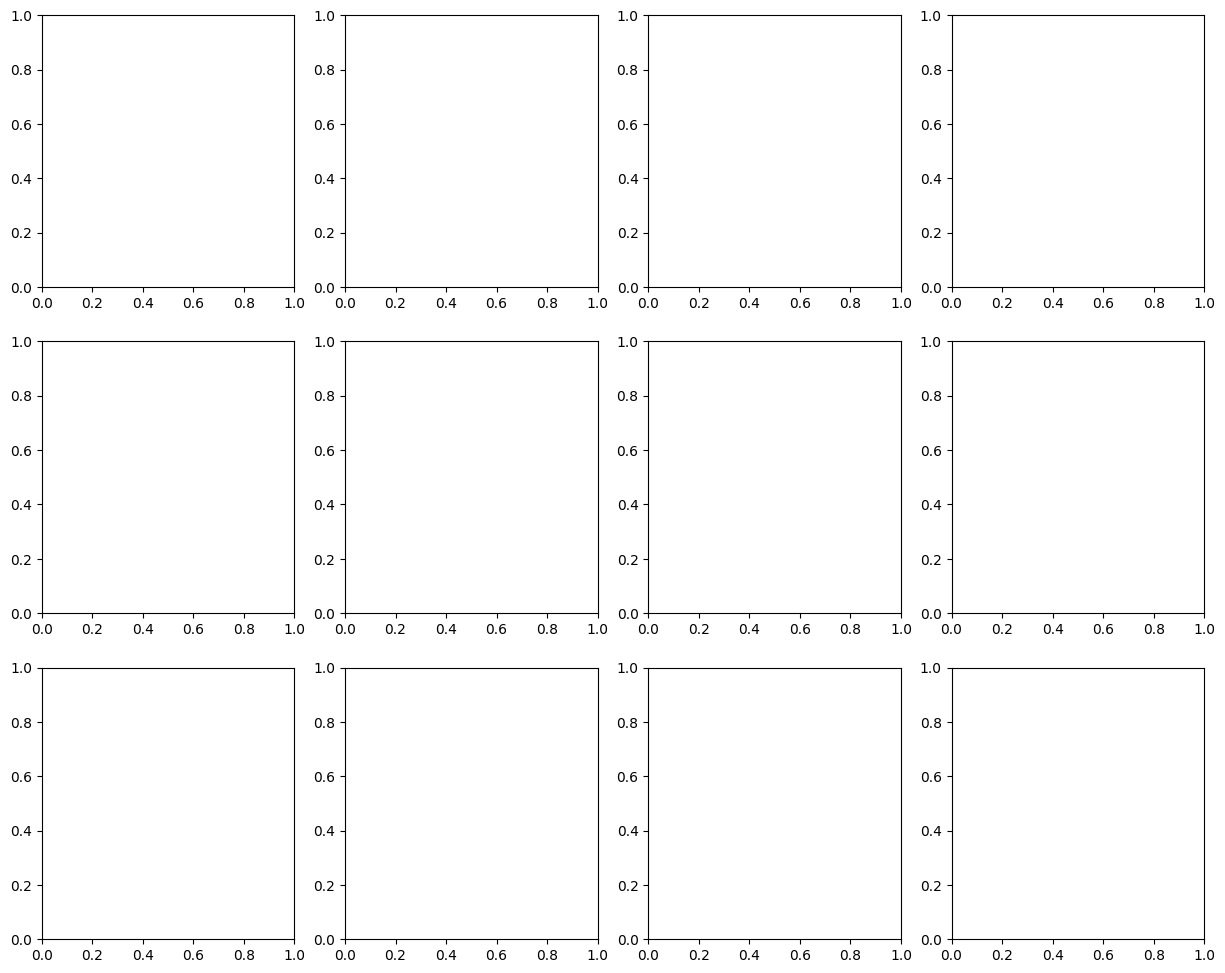

In [33]:
#isic.id.unique()
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

np.random.seed(11)
# Get 3 random IDs from training set
train_ids = isic[isic['Split'] == 'TRAIN']['id'].unique()

# Set up the plot
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
#fig.suptitle('Sample Images from ISIC. Same row means taken from the same patient.', fontsize=16)

# Base directory for images
base_dir = "/vol/ideadata/ed52egek/data/isic_2020/ISIC_2020_Training_JPEG/train"

isic = isic[isic.id.map(isic.id.value_counts())  > 3]

selected_ids = np.random.choice(isic.id.unique().tolist(), 3, replace=False)
# For each selected ID
for row, id_num in enumerate(selected_ids):
    # Get all samples for this ID, up to 4
    id_samples = isic[isic['id'] == id_num]['path']
    n_samples = min(4, len(id_samples))
    samples = id_samples.sample(n=n_samples).values
    
    # Plot each sample
    for col, img_path in enumerate(samples):
        img = Image.open(os.path.join(base_dir, img_path))
        img = img.resize((512, 512), Image.Resampling.LANCZOS)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
#        if col == 0:  # Only add ID label to first image in row
#            axes[row, col].set_title(f'ID: {id_num}')

plt.tight_layout()
plt.savefig("isic_samples.png")
plt.show()


In [ ]:
isic[isic.id.map(isic.id.value_counts())  > 3]

,Unnamed: 0,path,id,benign,malignant,Split
0,0,ISIC_2637011.jpg,0,1,0,TRAIN
1,1,ISIC_0015719.jpg,1,1,0,TRAIN
2,2,ISIC_0052212.jpg,2,1,0,TRAIN
3,3,ISIC_0068279.jpg,3,1,0,TRAIN
4,4,ISIC_0074268.jpg,4,1,0,TRAIN
...,...,...,...,...,...,...
32696,32696,ISIC_9999134.jpg,365,1,0,VAL
32697,32697,ISIC_9999320.jpg,798,1,0,TRAIN
32698,32698,ISIC_9999515.jpg,931,1,0,TRAIN
32699,32699,ISIC_9999666.jpg,860,1,0,TRAIN
